In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("food_coded.csv")
df.head(3)

,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155
2,3.3,1,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,...,1.0,2.0,5,1165.0,500,none,5,1,900,I'm not answering this.


In [4]:
print("Shape:", df.shape)
df.info()

Shape: (125, 61)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           123 non-null    object 
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    object 
 8   comfort_food_reasons          123 non-null    object 
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine                       108 non-null    f

### Data Cleaning

In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
GPA                  2
Gender               0
breakfast            0
calories_chicken     0
calories_day        19
                    ..
type_sports         26
veggies_day          0
vitamins             0
waffle_calories      0
weight               2
Length: 61, dtype: int64


In [6]:
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           123 non-null    object 
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    object 
 8   comfort_food_reasons          123 non-null    object 
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine                       108 non-null    float64
 13  diet_

In [9]:
cols_to_keep = ['GPA', 'Gender', 'breakfast', 'calories_chicken', 
                'calories_day', 'coffee', 'cook', 'eating_out', 
                'exercise', 'fav_food', 'fruit_day', 'veggies_day', 
                'vitamins', 'weight', 'healthy_feeling', 'income',
                'self_perception_weight', 'fav_cuisine_coded']

df = df[cols_to_keep]

# Clean GPA column (has messy values like "3.79 bitch", "Unknown", "Personal")
df['GPA'] = pd.to_numeric(df['GPA'], errors='coerce')

# Clean weight column (has "144 lbs", "I'm not answering this." etc)
df['weight'] = pd.to_numeric(df['weight'], errors='coerce')

# Drop rows where GPA or weight is missing
df = df.dropna(subset=['GPA', 'weight'])

# Fill remaining numeric nulls with median
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("\nCleaned shape:", df.shape)
df.head()


Cleaned shape: (115, 18)


,GPA,Gender,breakfast,calories_chicken,calories_day,coffee,cook,eating_out,exercise,fav_food,fruit_day,veggies_day,vitamins,weight,healthy_feeling,income,self_perception_weight,fav_cuisine_coded
0,2.400,2,1,430,3.0,1,2.0,3,1.0,1.0,5,5,1,187.0,2,5.0,3.0,3
1,3.654,1,1,610,3.0,2,3.0,2,1.0,1.0,4,4,2,155.0,5,4.0,3.0,1
4,3.500,1,1,720,2.0,2,1.0,2,1.0,3.0,4,4,2,190.0,6,6.0,4.0,1
5,2.250,1,1,610,3.0,2,3.0,1,2.0,3.0,2,1,2,190.0,4,1.0,5.0,6
6,3.800,2,1,610,3.0,2,2.0,2,1.0,1.0,4,4,1,180.0,4,4.0,4.0,4


In [10]:

df.describe()

,GPA,Gender,breakfast,calories_chicken,calories_day,coffee,cook,eating_out,exercise,fav_food,fruit_day,veggies_day,vitamins,weight,healthy_feeling,income,self_perception_weight,fav_cuisine_coded
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,3.423104,1.391304,1.104348,577.739130,3.026087,1.747826,2.800000,2.556522,1.521739,1.686957,4.243478,4.008696,1.530435,157.886957,5.469565,4.504348,3.078261,2.513043
std,0.391963,0.490178,0.307049,130.067869,0.569100,0.436161,0.992958,1.156153,0.653571,0.911575,0.932750,1.063721,0.501257,31.132080,2.583082,1.483085,1.077260,1.992817
min,2.200000,1.000000,1.000000,265.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000,1.000000,1.000000,1.000000,0.000000
25%,3.200000,1.000000,1.000000,430.000000,3.000000,1.500000,2.000000,2.000000,1.000000,1.000000,4.000000,3.000000,1.000000,135.000000,3.000000,3.500000,2.000000,1.000000
50%,3.500000,1.000000,1.000000,610.000000,3.000000,2.000000,3.000000,2.000000,1.000000,1.000000,5.000000,4.000000,2.000000,155.000000,5.000000,5.000000,3.000000,1.000000
75%,3.700000,2.000000,1.000000,665.000000,3.000000,2.000000,3.000000,3.000000,2.000000,3.000000,5.000000,5.000000,2.000000,177.500000,8.000000,6.000000,4.000000,4.000000
max,4.000000,2.000000,2.000000,720.000000,4.000000,2.000000,5.000000,5.000000,3.000000,3.000000,5.000000,5.000000,2.000000,265.000000,10.000000,6.000000,6.000000,8.000000


### EDA analysis

In [11]:
# Gender distribution
print("Gender Distribution:")
print(df['Gender'].value_counts())

# Average GPA
print("\nAverage GPA:", round(df['GPA'].mean(), 2))

# Average weight
print("Average Weight:", round(df['weight'].mean(), 2))

# Exercise habits
print("\nExercise Frequency:")
print(df['exercise'].value_counts())

# Breakfast habits
print("\nBreakfast Habits:")
print(df['breakfast'].value_counts())

Gender Distribution:
Gender
1    70
2    45
Name: count, dtype: int64

Average GPA: 3.42
Average Weight: 157.89

Exercise Frequency:
exercise
1.0    65
2.0    40
3.0    10
Name: count, dtype: int64

Breakfast Habits:
breakfast
1    103
2     12
Name: count, dtype: int64


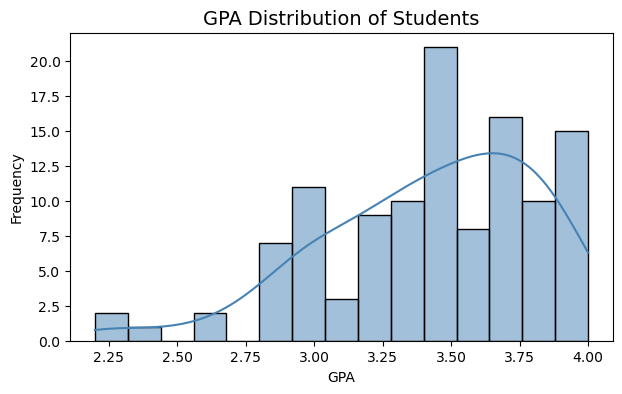

In [12]:
plt.figure(figsize=(7,4))
sns.histplot(df['GPA'], bins=15, color='steelblue', kde=True)
plt.title('GPA Distribution of Students', fontsize=14)
plt.xlabel('GPA')
plt.ylabel('Frequency')
plt.show()

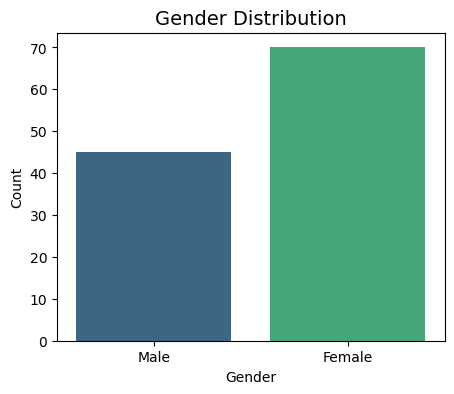

In [13]:
plt.figure(figsize=(5,4))
gender_map = {1: 'Female', 2: 'Male'}
df['Gender_label'] = df['Gender'].map(gender_map)
sns.countplot(x='Gender_label', data=df, palette='viridis', hue='Gender_label', legend=False)
plt.title('Gender Distribution', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

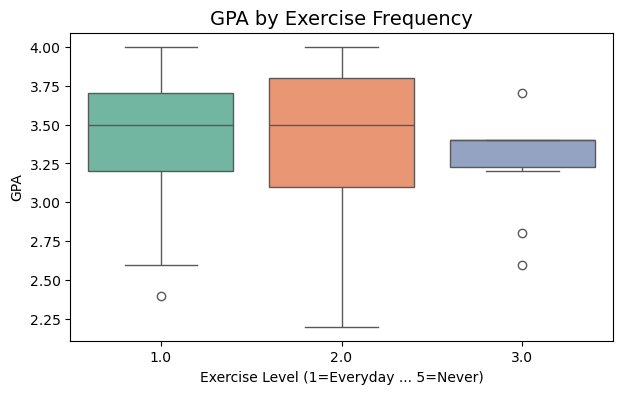

In [14]:
plt.figure(figsize=(7,4))
sns.boxplot(x='exercise', y='GPA', data=df, palette='Set2', hue='exercise', legend=False)
plt.title('GPA by Exercise Frequency', fontsize=14)
plt.xlabel('Exercise Level (1=Everyday ... 5=Never)')
plt.ylabel('GPA')
plt.show()

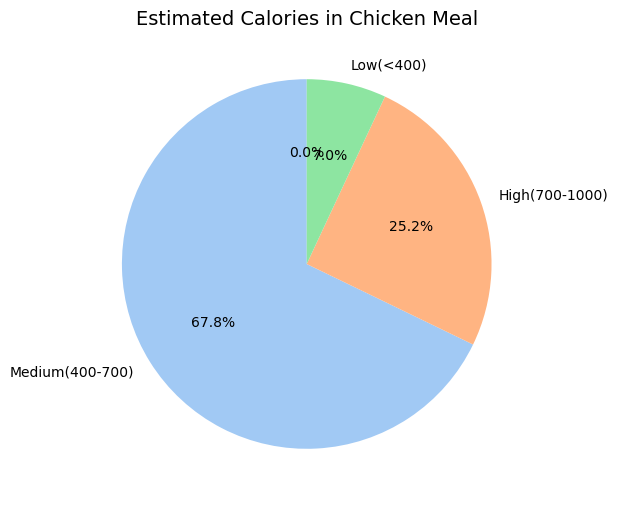

In [15]:
plt.figure(figsize=(6,6))
calorie_bins = pd.cut(df['calories_chicken'], bins=[0,400,700,1000,2000], 
                       labels=['Low(<400)', 'Medium(400-700)', 'High(700-1000)', 'Very High(>1000)'])
calorie_bins.value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Estimated Calories in Chicken Meal', fontsize=14)
plt.ylabel('')
plt.show()

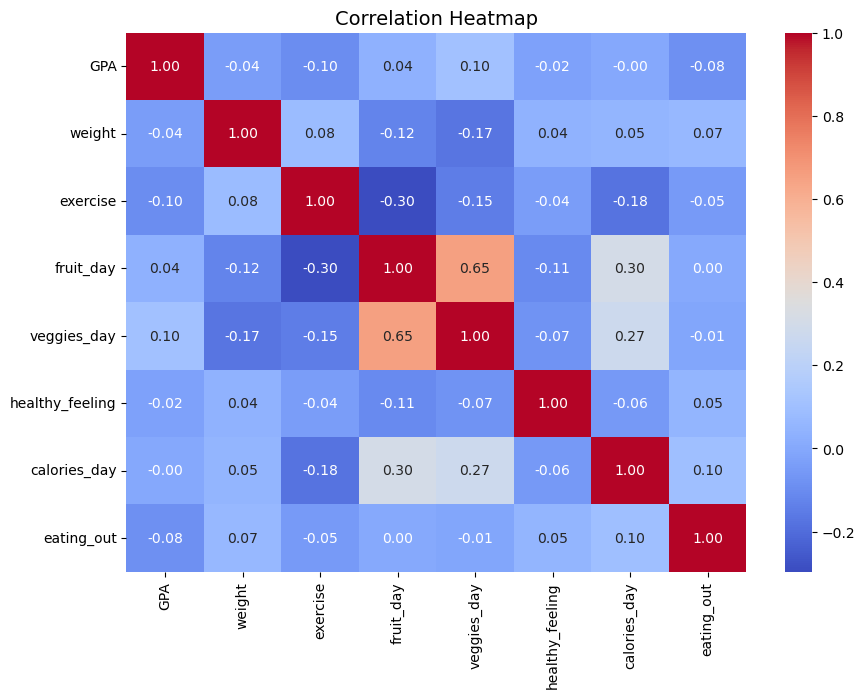

In [16]:
plt.figure(figsize=(10,7))
corr_cols = ['GPA', 'weight', 'exercise', 'fruit_day', 'veggies_day', 
             'healthy_feeling', 'calories_day', 'eating_out']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14)
plt.show()